In this notebook we explore Gaussian Processes for processing ESR data. Previous studies have demonstrated that GPs can achieve better than 1 K accuracy in spectra -> temperature mapping


In [1]:
# import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, grid, tight_layout
import datetime
# Make the Jupyter Notebook fill 90 percent of the screen (nerd_mode)
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

Index(['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20'],
      dtype='object')


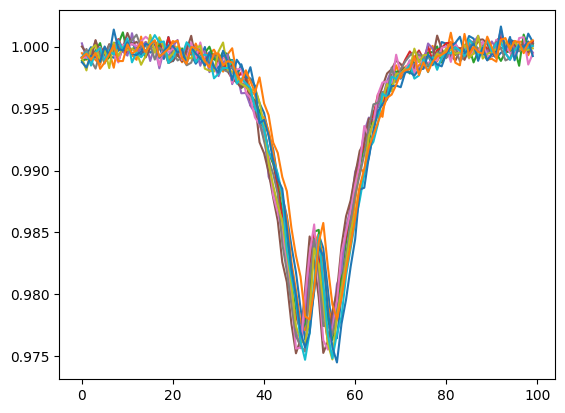

In [2]:
# load data and preprocess it 

temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

temps
## import data file
fpath = '../../esr_data/saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, :-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20"], inplace= True)
print(df.columns)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

#scale x axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()*100



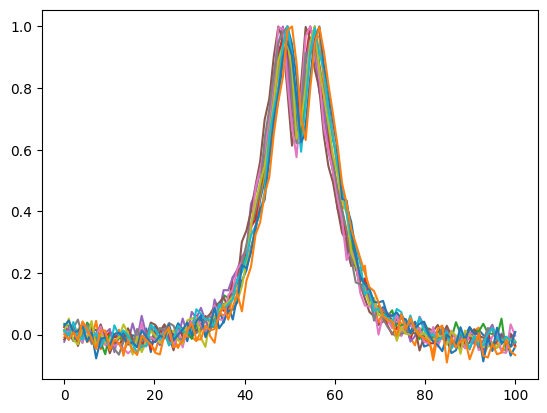

In [3]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr);
#plt.xlim(40, 80)

In [4]:

# Define GP kernel
kernel = ConstantKernel(1.0) * (Matern(length_scale=0.2, nu=1.5, length_scale_bounds=(0.05, 1.0)) \
        + Matern(length_scale=5, nu=2.5, length_scale_bounds=(1, 10)))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=False,
    n_restarts_optimizer=5
)
    

In [5]:
### Demo fitting of a single slice on GP

X = x_scale.reshape(-1,1)
y_ = y_esr.iloc[:,0]

gp.fit(X[0::2], y_[0::2])

# Predict mean and std
mu, std = gp.predict(X, return_std=True)
mu = mu.flatten()
std = std.flatten()



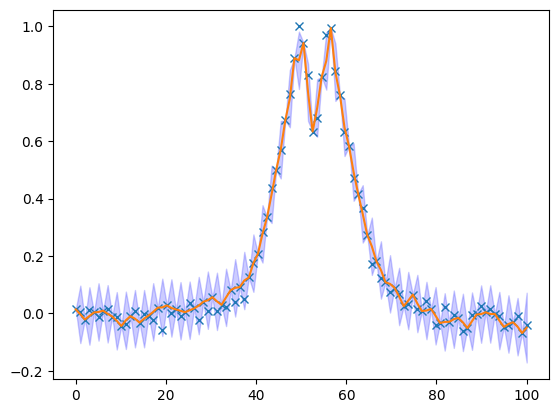

In [6]:
plt.plot(x_scale, y_, 'x')
plt.plot(x_scale, mu)
plt.fill_between(x_scale, mu - std, mu + std, alpha=0.2, color = 'blue')

Sparse sampling

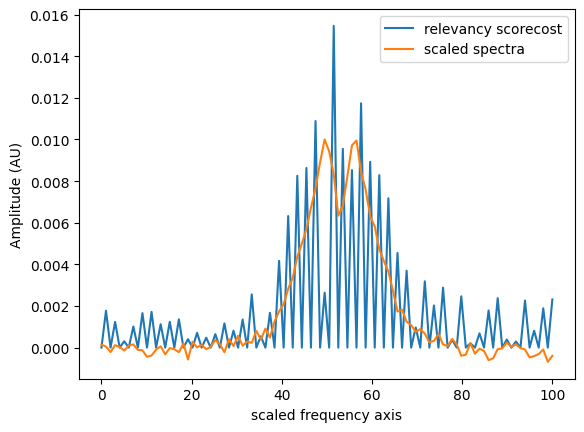

In [7]:
#### define an acqusition function that determines the next frequency point to sample #############

# uncertainty scaled predicted amplitude (relevancy score)
acquisition = std * np.abs(np.gradient(mu))

#sort acqusition function from highest relevance to lowest returning corresponding indicies 
sorted_idx = np.argsort(acquisition)[::-1]

plt.plot(x_scale, acquisition)
plt.plot(x_scale, y_*1e-2)
plt.xlabel('scaled frequency axis')
plt.ylabel('Amplitude (AU)')
plt.legend(['relevancy scorecost', 'scaled spectra'])

In [13]:
np.zeros((x_scale.shape[0]//10) ).shape


(10,)

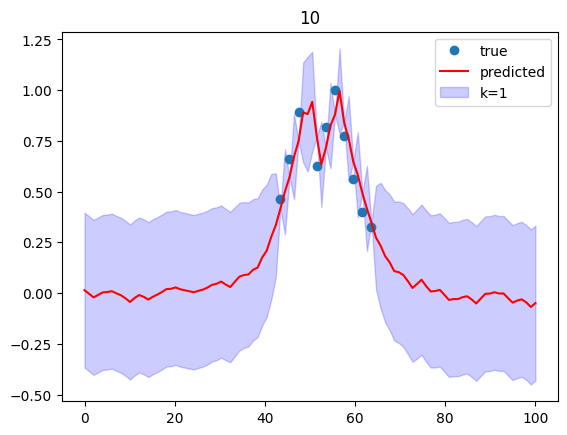

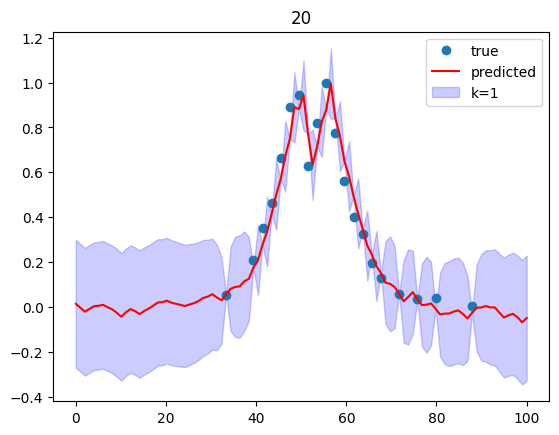

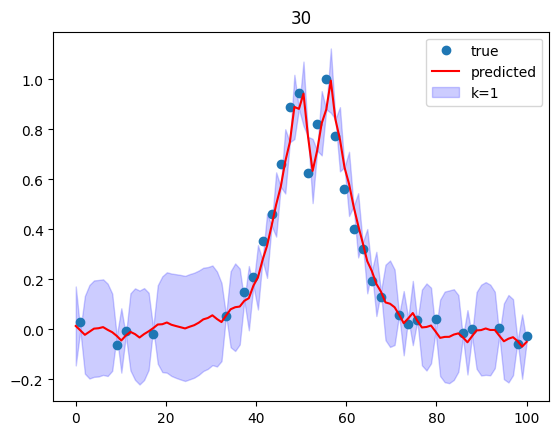

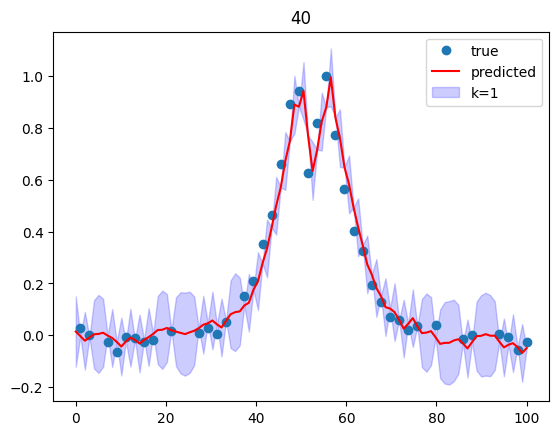

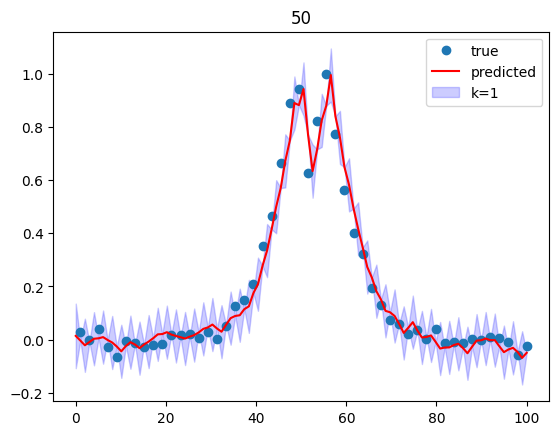

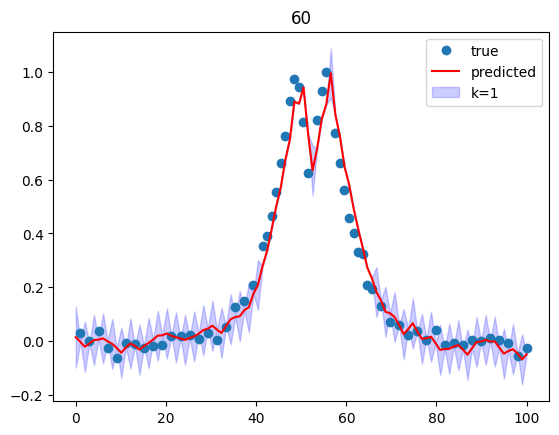

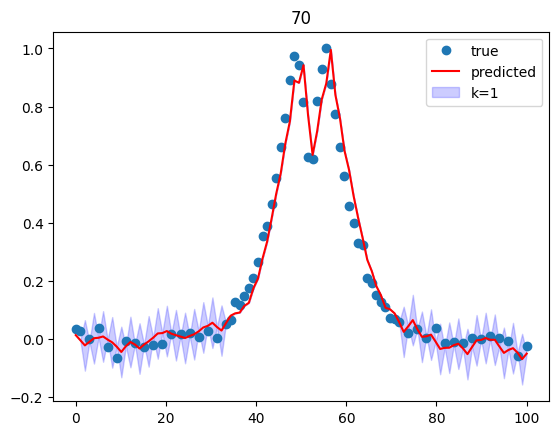

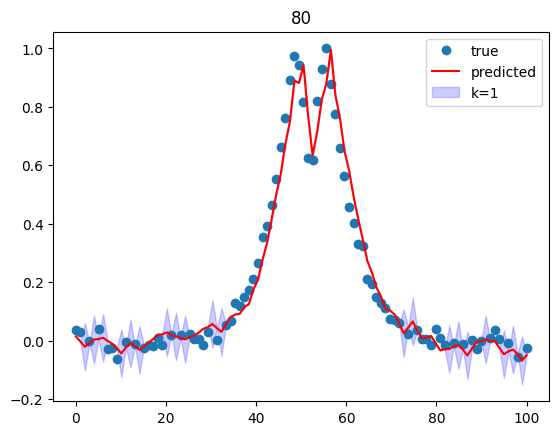

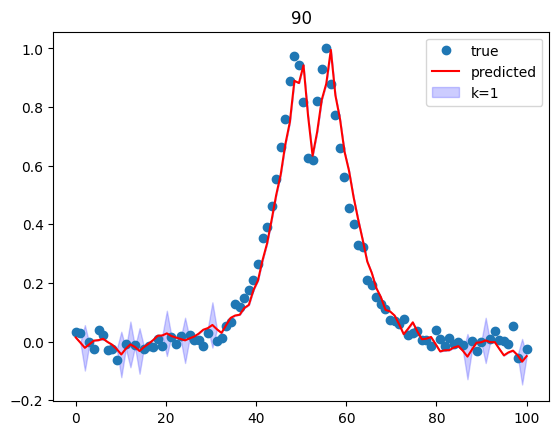

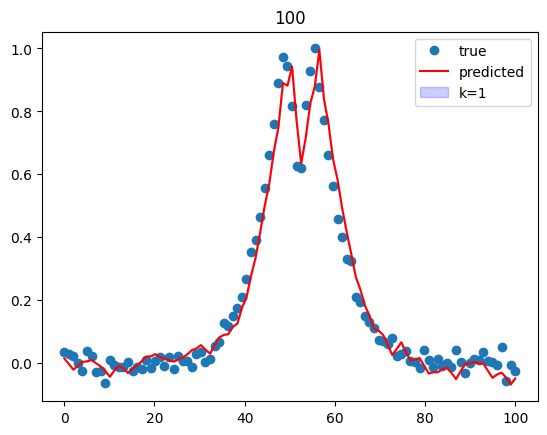

In [23]:
#### let's iterate over a spectra #####
y_new = y_esr.iloc[:, 2]


gp_ = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=False,
    n_restarts_optimizer=5
)

mean_std = np.zeros((x_scale.shape[0]//10))

for i_ in range(1, (x_scale.shape[0]//10)+1):
    i = i_*10
    gp_.fit(x_scale[sorted_idx[:i]].reshape(-1,1), y_new[sorted_idx[:i]])
    mu_, std_ = gp_.predict(X, return_std=True)
    mu = mu.flatten()
    std_ = std_.flatten()
    mean_std[i_-1] = std_.mean()
    plt.plot(x_scale[sorted_idx[:i]], y_new[sorted_idx[:i]], 'o')
    plt.plot(x_scale, mu, 'r')
    plt.fill_between(x_scale, mu - std_, mu + std_, alpha=0.2, color = 'blue')
    plt.legend(['true', 'predicted', 'k=1'])
    plt.title(i)
    plt.show()


Text(0.5, 0, 'data points sampled')

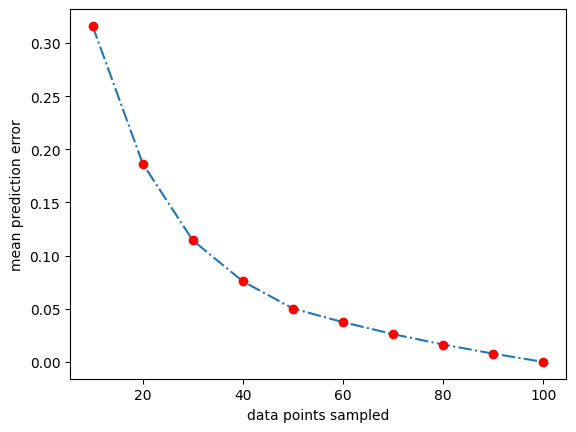

In [42]:
plt.plot(np.arange(10,101, 10), mean_std, '-.')
plt.plot(np.arange(10,101, 10), mean_std, 'ro')
plt.ylabel('mean prediction error')
plt.xlabel('data points sampled')

In [ ]:
print(f'max stdev {mean_std.max():.6f}, min stdev {mean_std.min():.6f}')

max stdev 0.316067, min stdev 0.000010
